<a href="https://colab.research.google.com/github/myDream616828/CF_Mai23280018_Minh23280029/blob/main/%5BCF%5D_VWMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install backtesting pandas numpy yfinance pmdarima arch pandas_ta


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
from arch import arch_model
from backtesting import Strategy, Backtest
from backtesting.lib import crossover
import yfinance as yf
import warnings
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')
DATA_FOLDER = "data"
CAPITAL = 100000.0
MAX_RISK_PCT = 0.01
K = 2.0
SL_FACTOR = 3.0
RR_RATIO = 2.0  # Tỷ lệ R:R
VWMA_PERIOD_SHORT = 10
VWMA_PERIOD_LONG = 30
NUM_CORES = -1  # Sử dụng tất cả các lõi CPU có sẵn
START_DATE='2015-01-01'
END_DATE='2025-10-01'

/usr/local/lib/python3.12/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


In [4]:

github_repo_link = "https://github.com/myDream616828/CF_Mai23280018_Minh23280029"
local_folder_name = "data_70_stock_new" # Tên thư mục sẽ được tạo trong Colab

# 1. Clone (Sao chép) Repository
# Dấu '!' cho phép chạy lệnh terminal (Bash) trong Colab
!git clone {github_repo_link} {local_folder_name}

# 2. Xem cấu trúc thư mục (Tùy chọn)
# Lệnh này xác nhận các file đã được tải về
!ls -l {local_folder_name}


Cloning into 'data_70_stock_new'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 100 (delta 10), reused 75 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 12.43 MiB | 7.53 MiB/s, done.
Resolving deltas: 100% (10/10), done.
total 56
-rw-r--r-- 1 root root 48104 Dec  4 13:31 '[CF]_VWMA.ipynb'
drwxr-xr-x 2 root root  4096 Dec  4 13:31  data
-rw-r--r-- 1 root root    30 Dec  4 13:31  README.md


In [7]:
import pandas as pd
import numpy as np
import os

# --- THÔNG SỐ CẤU HÌNH ---
DATA_FOLDER = "/content/data_70_stock_new/data"
INITIAL_CAPITAL = 100000.00
TRADING_DAYS_PER_YEAR = 252
ICHIMOKU_PARAMS = (9, 26, 52)
VWMA_PERIOD = 20

# --- KHAI BÁO TÊN CỘT CỦA BẠN (CẦN KIỂM TRA CHÍNH XÁC) ---
# Dựa trên file CSV của bạn, hãy điền tên cột chính xác:
DATE_COL = 'Date' # Ví dụ: 'Date', 'ds', 'Ngày'
CLOSE_COL = 'Close' # Ví dụ: 'Close', 'Adj Close', 'Gia_Dong_Cua'
VOLUME_COL = 'Volume' # Ví dụ: 'Volume', 'Volume (Shares)'

all_tickers = {}
file_list = [f for f in os.listdir(DATA_FOLDER) if f.lower().endswith(".csv")]

print(f"Bắt đầu tải {len(file_list)} mã cổ phiếu...")

for filename in file_list:
    file_path = os.path.join(DATA_FOLDER, filename)
    ticker = filename.replace(".csv", "").replace(".CSV", "").upper()

    try:
        df = pd.read_csv(
            file_path,
            index_col=DATE_COL,
            parse_dates=True,
            thousands=',' # Xử lý dấu phẩy trong số (nếu có)
        )

        # Chuẩn hóa tên cột để code tính toán có thể sử dụng:
        df.rename(columns={CLOSE_COL: 'Close', VOLUME_COL: 'Volume'}, inplace=True)

        # Đảm bảo cột giá và khối lượng là dạng số
        df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
        df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
        df.dropna(subset=['Close', 'Volume'], inplace=True)

        all_tickers[ticker] = df
        print(f"-> Tải thành công và chuẩn hóa: {ticker}")

    except Exception as e:
        print(f"*** LỖI khi tải {ticker}: {e}")

print(f"\n✅ Hoàn tất tải! {len(all_tickers)}/70 DataFrames đã sẵn sàng.")

Bắt đầu tải 1 mã cổ phiếu...
-> Tải thành công và chuẩn hóa: STOCK_DATA_70

✅ Hoàn tất tải! 1/70 DataFrames đã sẵn sàng.


In [10]:
import pandas as pd
import numpy as np
import os

# --- THÔNG SỐ CẤU HÌNH ---
# Tên file tải lên duy nhất chứa dữ liệu của tất cả 70 mã
DATA_FILE = "/content/data_70_stock_new/data/stock_data_70.csv"
INITIAL_CAPITAL = 100000.00
TRADING_DAYS_PER_YEAR = 252
# Tham số Ichimoku tiêu chuẩn
ICHIMOKU_PARAMS = (9, 26, 52)
VWMA_PERIOD = 20

# --- KHAI BÁO TÊN CỘT CỦA BẠN ---
DATE_COL = 'Date'
CLOSE_COL = 'Close'
VOLUME_COL = 'Volume'
TICKER_COL = 'Ticker'

all_tickers = {}

# --- 1. HÀM TÍNH TOÁN CHỈ SỐ ICHIMOKU ---
def calculate_ichimoku(df, n1=9, n2=26, n3=52):
    """Tính toán các đường Ichimoku: Tenkan, Kijun, SSA, SSB, Chikou."""

    if not all(col in df.columns for col in ['Open', 'High', 'Low', 'Close']):
        print("Lỗi: DataFrame thiếu các cột giá Open, High, Low, Close.")
        return df

    # Tenkan-sen (Conversion Line): Trung bình (Cao nhất + Thấp nhất) 9 phiên
    df['Tenkan-sen'] = (df['High'].rolling(window=n1).max() + df['Low'].rolling(window=n1).min()) / 2

    # Kijun-sen (Base Line): Trung bình (Cao nhất + Thấp nhất) 26 phiên
    df['Kijun-sen'] = (df['High'].rolling(window=n2).max() + df['Low'].rolling(window=n2).min()) / 2

    # Senkou Span A (Leading Span A): Trung bình (Tenkan + Kijun), dịch 26 phiên về phía trước
    df['Senkou Span A'] = ((df['Tenkan-sen'] + df['Kijun-sen']) / 2).shift(n2)

    # Senkou Span B (Leading Span B): Trung bình (Cao nhất + Thấp nhất) 52 phiên, dịch 26 phiên về phía trước
    df['Senkou Span B'] = ((df['High'].rolling(window=n3).max() + df['Low'].rolling(window=n3).min()) / 2).shift(n2)

    # Kumo Top/Bottom (Dùng để xác định bộ lọc Mây Kumo)
    df['Kumo_Top'] = df[['Senkou Span A', 'Senkou Span B']].max(axis=1)
    df['Kumo_Bottom'] = df[['Senkou Span A', 'Senkou Span B']].min(axis=1)

    # Chikou Span (Lagging Span): Giá đóng cửa dịch lùi 26 phiên
    df['Chikou Span'] = df['Close'].shift(-n2)

    return df

# --- 2. HÀM TÍNH TOÁN CHỈ SỐ VWMA (Cần thiết nếu sử dụng thêm VWMA) ---
def calculate_vwma(df, period):
    """Tính toán Volume Weighted Moving Average (VWMA)."""
    # VWMA = Sum(Close * Volume) / Sum(Volume)
    df['Close_Volume'] = df['Close'] * df['Volume']
    df['VWMA'] = df['Close_Volume'].rolling(window=period).sum() / df['Volume'].rolling(window=period).sum()
    df.drop(columns=['Close_Volume'], inplace=True)
    return df


# --- 3. QUÁ TRÌNH TẢI VÀ CHUẨN BỊ DỮ LIỆU ---

print(f"Bắt đầu tải dữ liệu từ file {DATA_FILE} và chia nhỏ theo mã cổ phiếu...")

try:
    # 3.1. Tải toàn bộ file CSV
    df_full = pd.read_csv(
        DATA_FILE,
        parse_dates=[DATE_COL],
        thousands=',',
    )

    # 3.2. Chuẩn hóa và xử lý dữ liệu
    df_full.rename(columns={CLOSE_COL: 'Close', VOLUME_COL: 'Volume'}, inplace=True)

    # Đảm bảo các cột giá và khối lượng là dạng số
    # Thêm 'Open', 'High', 'Low' vào đây để đảm bảo tính toán Ichimoku hoạt động
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce')

    df_full.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)

    # 3.3. Chia nhỏ DataFrame theo cột Ticker và tính Ichimoku/VWMA
    tickers_list = df_full[TICKER_COL].unique()

    for ticker in tickers_list:
        # Lấy DataFrame của riêng mã cổ phiếu này
        df_ticker = df_full[df_full[TICKER_COL] == ticker].set_index(DATE_COL)

        # Sắp xếp lại theo ngày (rất quan trọng cho backtest)
        df_ticker.sort_index(inplace=True)

        # Loại bỏ cột Ticker không cần thiết trong DF con
        df_ticker = df_ticker.drop(columns=[TICKER_COL, 'Adj Close'], errors='ignore')

        # TÍNH TOÁN CÁC CHỈ SỐ KỸ THUẬT
        df_ticker = calculate_ichimoku(df_ticker, *ICHIMOKU_PARAMS)
        df_ticker = calculate_vwma(df_ticker, VWMA_PERIOD)

        # Lưu DataFrame đã được xử lý
        all_tickers[ticker] = df_ticker

    print(f"-> Tải thành công và tính toán chỉ số cho {len(tickers_list)} mã cổ phiếu.")

except FileNotFoundError:
    print(f"*** LỖI: Không tìm thấy file {DATA_FILE}. Vui lòng kiểm tra lại tên file đã tải lên.")
except Exception as e:
    print(f"*** LỖI khi tải hoặc xử lý dữ liệu: {e}")

print(f"\n✅ Hoàn tất tải! {len(all_tickers)} DataFrames đã sẵn sàng cho backtest.")

Bắt đầu tải dữ liệu từ file /content/data_70_stock_new/data/stock_data_70.csv và chia nhỏ theo mã cổ phiếu...
-> Tải thành công và tính toán chỉ số cho 70 mã cổ phiếu.

✅ Hoàn tất tải! 70 DataFrames đã sẵn sàng cho backtest.


In [11]:

#Dự báo biến động Garch
def garch_rolling_forecast(returns_series, lookback_window=252):

    sigma_forecasts = [np.nan] * lookback_window

    scaling_factor = 100
    scaled_returns = returns_series * scaling_factor

    # Lặp qua dữ liệu để tính GARCH Rolling Forecast
    for i in range(lookback_window, len(returns_series)):
        window = scaled_returns.iloc[i - lookback_window : i]

        try:
            # --- ĐƠN GIẢN HÓA: THAY mean='Constant' BẰNG mean='zero' ---
            # Chỉ tập trung vào việc ước tính biến động (tăng tốc độ)
            am = arch_model(window, vol='Garch', p=1, q=1, mean='zero', dist='normal')

            res = am.fit(
                disp='off',
                max_iter=75,
                options={'ftol': 1e-5}
            )

            # Dự báo Độ lệch chuẩn (Sigma) cho ngày t+1
            forecasts = res.forecast(horizon=1)
            sigma = np.sqrt(forecasts.variance.iloc[-1, 0])
            sigma /= scaling_factor

        except Exception:
            # Giữ giá trị sigma cũ hoặc default
            sigma = sigma_forecasts[-1] if sigma_forecasts[-1] is not np.nan else 0.01

        sigma_forecasts.append(sigma)

    return pd.Series(sigma_forecasts, index=returns_series.index)

In [12]:
#Tải Dữ liệu và Tính Toán Features
def prepare_data_with_features(ticker_symbol, start_date, end_date):
    if ticker_symbol not in all_tickers:
        raise ValueError(f"Ticker '{ticker_symbol}' not found in the global all_tickers dictionary.")

    df = all_tickers[ticker_symbol].copy()


    df = df.loc[start_date:end_date]

    if 'Adj Close' in df.columns:
        df['Close'] = df['Adj Close']
        df = df.drop(columns=['Adj Close'])
    elif 'Close' not in df.columns:
        raise ValueError("Không tìm thấy cột 'Close' hoặc 'Adj Close' trong dữ liệu.")


    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
    df.dropna(subset=['Close', 'Volume'], inplace=True)

    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))


    df.dropna(inplace=True)
    return df


for data, ticker in zip(all_tickers.values(), all_tickers.keys()):
 data = prepare_data_with_features(ticker, START_DATE, END_DATE)
 data.dropna(inplace=True)


In [13]:


# Tắt cảnh báo có thể gây chậm Colab
warnings.filterwarnings('ignore')
pd.set_option('mode.chained_assignment', None)


# --- 3. CLASS CHIẾN LƯỢC (VWMA+GARCH CÓ TP ĐỘNG) ---
class VWMACGARCHStrategy(Strategy):
    risk_per_trade = MAX_RISK_PCT
    K = K
    sl_factor = SL_FACTOR
    rr_ratio = RR_RATIO

    def init(self):
        self.vwma_short = self.I(lambda x: x, self.data.VWMA_10)
        self.vwma_long = self.I(lambda x: x, self.data.VWMA_30)
        self.garch_sigma = self.I(lambda x: x, self.data.GARCH_Sigma)
        self.price = self.data.Close

    def next(self):
        current_price = self.data.Close[-1]
        sigma_t_plus_1 = self.garch_sigma[-1]
        current_equity = self.equity

        if sigma_t_plus_1 <= 0 or np.isnan(sigma_t_plus_1): return

        # TÍNH KÍCH THƯỚC VỊ THẾ (Position Sizing)
        dynamic_risk_per_share = self.K * current_price * sigma_t_plus_1
        max_risk_per_trade = current_equity * self.risk_per_trade

        if dynamic_risk_per_share <= 0: return

        position_size = max_risk_per_trade / dynamic_risk_per_share
        target_size = int(position_size)

        # KHOẢNG CÁCH SL VÀ TP
        sl_distance = self.sl_factor * current_price * sigma_t_plus_1
        tp_distance = self.rr_ratio * sl_distance

        # TẠO TÍN HIỆU VÀ ĐẶT LỆNH
        if crossover(self.vwma_short, self.vwma_long):
            # Tín hiệu MUA (Long)
            sl_price = current_price - sl_distance
            tp_price = current_price + tp_distance

            if not self.position.is_long:
                self.position.close()
                self.buy(size=target_size, sl=sl_price, tp=tp_price)

        elif crossover(self.vwma_long, self.vwma_short):
            # Tín hiệu BÁN (Short)
            sl_price = current_price + sl_distance
            tp_price = current_price - tp_distance

            if not self.position.is_short:
                self.position.close()
                self.sell(size=abs(target_size), sl=sl_price, tp=tp_price)

# --- 4. HÀM XỬ LÝ ĐƠN LẺ (SINGLE TICKER PROCESSOR) ---
def process_single_ticker(ticker, data_original, capital):
    data = data_original.copy()

    if len(data) < 60: return None

    try:
        # TÍNH INDICATOR
        data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
        data['VWMA_10'] = ta.vwma(data['Close'], data['Volume'], length=VWMA_PERIOD_SHORT)
        data['VWMA_30'] = ta.vwma(data['Close'], data['Volume'], length=VWMA_PERIOD_LONG)
        data['GARCH_Sigma'] = garch_rolling_forecast(data['Log_Return'])

        data.dropna(inplace=True)
        if data.empty: return None

    except Exception as e:
        print(f"LỖI TÍNH INDICATOR {ticker}: {e}")
        return None

    # CHẠY BACKTEST
    try:
        bt = Backtest(data, VWMACGARCHStrategy,
                      cash=capital, commission=.002, exclusive_orders=True)

        stats = bt.run()

        return {
            'Ticker': ticker,
            'Final_Equity': stats['Equity Final [$]'],
            'Annual_Return_Pct': stats['Return (Ann.) [%]'],
            'Max. Drawdown_Pct': stats['Max. Drawdown [%]'],
            'Sharpe_Ratio': stats['Sharpe Ratio'],
            'Win_Rate_Pct': stats['Win Rate [%]'],
            'Total_Trades': stats['# Trades']
        }

    except Exception as e:
        print(f"LỖI CHẠY BACKTEST {ticker}: {e}")
        return None

# =================================================================
# KHỐI 3: TẢI DATA VÀ THỰC THI SONG SONG
# =================================================================

# 1. Tải dữ liệu vào all_tickers (GIẢ ĐỊNH BẠN ĐÃ CHẠY CODE TẢI DỮ LIỆU)
# all_tickers = {...}

# 2. CHẠY THỰC THI SONG SONG (TỐI ƯU TỐC ĐỘ)
print("\n--- BẮT ĐẦU THỰC THI SONG SONG (VWMA+GARCH) ---")
results_list = Parallel(n_jobs=NUM_CORES)(
    delayed(process_single_ticker)(ticker, data, CAPITAL)
    for ticker, data in all_tickers.items()
)

# 3. TỔNG HỢP VÀ HIỂN THỊ KẾT QUẢ
final_results = [res for res in results_list if res is not None]
performance_summary_df_VWMA = pd.DataFrame(final_results)

if not performance_summary_df_VWMA.empty:
    performance_summary_df_VWMA.set_index('Ticker', inplace=True)
    performance_summary_df_VWMA.sort_values(by='Sharpe_Ratio', ascending=False, inplace=True)

    print("\n--- KẾT QUẢ BACKTEST TỔNG HỢP (Tối ưu hóa tốc độ) ---")
performance_summary_df_VWMA



--- BẮT ĐẦU THỰC THI SONG SONG (VWMA+GARCH) ---

--- KẾT QUẢ BACKTEST TỔNG HỢP (Tối ưu hóa tốc độ) ---


,Final_Equity,Annual_Return_Pct,Max. Drawdown_Pct,Sharpe_Ratio,Win_Rate_Pct,Total_Trades
Ticker,,,,,,
LMT,131307.539261,2.598116,-20.302506,0.438316,39.449541,109
PG,126181.802258,2.214122,-12.321900,0.374715,45.161290,93
MPC,120463.274520,1.768674,-25.096969,0.255483,41.584158,101
BRK-B,110919.574814,0.980715,-13.858591,0.166147,37.864078,103
HD,109305.368713,0.841404,-19.826193,0.144263,37.755102,98
...,...,...,...,...,...,...
EQIX,59661.606444,-4.747342,-45.051866,-0.781975,25.000000,104
MS,55065.714775,-5.463682,-46.092947,-0.913977,24.107143,112
CVX,52854.012764,-5.827925,-49.993773,-0.941050,24.576271,118


In [14]:
top_5_stocks_VWMA = performance_summary_df_VWMA.sort_values(by='Sharpe_Ratio', ascending=False).head(5)
display(top_5_stocks_VWMA)

,Final_Equity,Annual_Return_Pct,Max. Drawdown_Pct,Sharpe_Ratio,Win_Rate_Pct,Total_Trades
Ticker,,,,,,
LMT,131307.539261,2.598116,-20.302506,0.438316,39.449541,109
PG,126181.802258,2.214122,-12.321900,0.374715,45.161290,93
MPC,120463.274520,1.768674,-25.096969,0.255483,41.584158,101
BRK-B,110919.574814,0.980715,-13.858591,0.166147,37.864078,103
HD,109305.368713,0.841404,-19.826193,0.144263,37.755102,98


In [15]:
import pandas as pd
import numpy as np

# Giả định all_tickers đã được tải và chứa các DataFrames
# all_tickers = {'TSLA': df_tsla, 'MSFT': df_msft, ...}

# --- THAM SỐ ICHIMOKU (Cố định) ---
SHIFT = 26
ICHIMOKU_PARAMS = (9, 26, 52)
n1, n2, n3 = ICHIMOKU_PARAMS
# -----------------------------------


# --- 1. Hàm tính toán Ichimoku Kinko Hyo ---
def calculate_ichimoku(df_input, n1=9, n2=26, n3=52, shift=26):
    df = df_input.copy()
    # Đảm bảo dữ liệu đủ dài cho N3=52
    if len(df) < n3 + shift:
        # Trả về df ban đầu hoặc một bản sao rỗng nếu không đủ dữ liệu
        return df.copy() # Hoặc pd.DataFrame(columns=df.columns) nếu muốn rỗng

    # a. Tính Tenkan-sen (TS - Đường chuyển đổi)
    df['Tenkan-sen'] = (df['High'].rolling(window=n1).max() + df['Low'].rolling(window=n1).min()) / 2

    # b. Tính Kijun-sen (KS - Đường tiêu chuẩn)
    df['Kijun-sen'] = (df['High'].rolling(window=n2).max() + df['Low'].rolling(window=n2).min()) / 2

    # c. Tính Senkou Span A (SSA - Đường Dẫn A)
    df['Senkou Span A'] = ((df['Tenkan-sen'] + df['Kijun-sen']) / 2).shift(shift)

    # d. Tính Senkou Span B (SSB - Đường Dẫn B)
    df['Senkou Span B'] = ((df['High'].rolling(window=n3).max() + df['Low'].rolling(window=n3).min()) / 2).shift(shift)

    # e. Tính Chikou Span (CS - Đường trễ)
    # Chikou Span phải được shift ngược lại (-shift) để khớp với giá hiện tại
    # Tuy nhiên, trong mplfinance, nó được vẽ ở vị trí tương lai. Tín hiệu Chikou dựa vào giá quá khứ.
    # Để thống nhất với logic tín hiệu, ta sẽ giữ shift âm.
    df['Chikou Span'] = df['Close'].shift(-shift)

    # f. Tính toán Màu của Mây và Biên Mây
    # df['Kumo Color'] = np.where(df['Senkou Span A'] > df['Senkou Span B'], 'Green', 'Red') # Không cần cho plotting trực tiếp
    df['Kumo_Top'] = df[['Senkou Span A', 'Senkou Span B']].max(axis=1)
    df['Kumo_Bottom'] = df[['Senkou Span A', 'Senkou Span B']].min(axis=1)

    # Đảm bảo các cột quan trọng cho Ichimoku có đủ dữ liệu
    return df.dropna(subset=['Tenkan-sen', 'Kijun-sen', 'Senkou Span A', 'Senkou Span B', 'Chikou Span'])

# --- 2. VÒNG LẶP THỰC THI (CHO TẤT CẢ 70 MÃ) ---

ichimoku_summary = {}

for ticker, df in all_tickers.items():

    # 1. Tạo bản sao để tính toán
    df_ichimoku = df.copy()

    # 2. Tính toán Ichimoku
    df_ichimoku = calculate_ichimoku(df_ichimoku, n1, n2, n3, SHIFT)

    # 3. Cập nhật lại DataFrame gốc trong Dictionary
    all_tickers[ticker] = df_ichimoku

    # 4. Ghi nhận kết quả (Tùy chọn)
    ichimoku_summary[ticker] = len(df_ichimoku)

    print(f"✅ Hoàn tất tính toán Ichimoku cho mã: {ticker}")

print(f"\nTổng cộng {len(all_tickers)} mã đã được tính toán. Dữ liệu đã được cập nhật.")

✅ Hoàn tất tính toán Ichimoku cho mã: AAPL
✅ Hoàn tất tính toán Ichimoku cho mã: ABBV
✅ Hoàn tất tính toán Ichimoku cho mã: ADBE
✅ Hoàn tất tính toán Ichimoku cho mã: AEP
✅ Hoàn tất tính toán Ichimoku cho mã: AMD
✅ Hoàn tất tính toán Ichimoku cho mã: AMT
✅ Hoàn tất tính toán Ichimoku cho mã: AMZN
✅ Hoàn tất tính toán Ichimoku cho mã: APD
✅ Hoàn tất tính toán Ichimoku cho mã: AVGO
✅ Hoàn tất tính toán Ichimoku cho mã: BA
✅ Hoàn tất tính toán Ichimoku cho mã: BAC
✅ Hoàn tất tính toán Ichimoku cho mã: BRK-B
✅ Hoàn tất tính toán Ichimoku cho mã: CAT
✅ Hoàn tất tính toán Ichimoku cho mã: CCI
✅ Hoàn tất tính toán Ichimoku cho mã: CMCSA
✅ Hoàn tất tính toán Ichimoku cho mã: COP
✅ Hoàn tất tính toán Ichimoku cho mã: COST
✅ Hoàn tất tính toán Ichimoku cho mã: CRM
✅ Hoàn tất tính toán Ichimoku cho mã: CVX
✅ Hoàn tất tính toán Ichimoku cho mã: DIS
✅ Hoàn tất tính toán Ichimoku cho mã: DUK
✅ Hoàn tất tính toán Ichimoku cho mã: ECL
✅ Hoàn tất tính toán Ichimoku cho mã: ED
✅ Hoàn tất tính toán Ichim

In [16]:
import pandas as pd
import numpy as np
import math

# --- KHAI BÁO CÁC THAM SỐ TOÀN CỤC ---
# Giả định các biến này đã được định nghĩa ở phần tải dữ liệu
INITIAL_CAPITAL = 100000.0
TRADING_DAYS_PER_YEAR = 252
SHIFT = 26


# --- 1. HÀM MÔ PHỎNG GIAO DỊCH (T-K Crossover + SL Kijun) ---
def backtest_ichimoku_tk_crossover(df, initial_capital):

    # LOGIC TÍN HIỆU ENTRY
    crossover_up = (df['Tenkan-sen'].shift(1) < df['Kijun-sen'].shift(1)) & (df['Tenkan-sen'] >= df['Kijun-sen'])
    crossover_down = (df['Tenkan-sen'].shift(1) > df['Kijun-sen'].shift(1)) & (df['Tenkan-sen'] <= df['Kijun-sen'])

    # Bộ lọc Mây Kumo
    above_kumo = (df['Close'] > df['Kumo_Top'])
    below_kumo = (df['Close'] < df['Kumo_Bottom'])

    # Chikou Span (Sử dụng cột đã tính toán)
    # Lưu ý: cs_above/below_price chỉ có thể kiểm tra sau khi tính Ichimoku
    cs_above_price = (df['Chikou Span'] > df['Close'].shift(SHIFT))
    cs_below_price = (df['Chikou Span'] < df['Close'].shift(SHIFT))

    df['Signal'] = 0
    # Long: T-K Crossover Up + Above Kumo + Chikou Above Price
    df['Signal'] = np.where(crossover_up & above_kumo & cs_above_price, 1, 0)
    # Short: T-K Crossover Down + Below Kumo + Chikou Below Price
    df['Signal'] = np.where(crossover_down & below_kumo & cs_below_price, -1, df['Signal'])

    # MÔ PHỎNG THỰC THI
    trades = []
    equity_curve = [initial_capital]
    capital = initial_capital
    position = 0
    entry_price = 0 # Khởi tạo entry_price

    for i in range(1, len(df)):
        current = df.iloc[i]

        # --- Xử lý THOÁT LỆNH (SL: Giá đóng cửa cắt Kijun-sen) ---

        # Thoát MUA (Position == 1)
        if position == 1 and current['Close'] < current['Kijun-sen']:
            pnl = (current['Close'] - entry_price) / entry_price
            capital *= (1 + pnl)
            trades.append({'P&L': pnl, 'Direction': 'Long'})
            position = 0

        # Thoát BÁN (Position == -1)
        elif position == -1 and current['Close'] > current['Kijun-sen']:
            pnl = (entry_price - current['Close']) / entry_price
            capital *= (1 + pnl)
            trades.append({'P&L': pnl, 'Direction': 'Short'})
            position = 0

        # --- Xử lý VÀO LỆNH ---
        if position == 0:
            if current['Signal'] == 1:
                position = 1
                entry_price = current['Close']
            elif current['Signal'] == -1:
                position = -1
                entry_price = current['Close']

        equity_curve.append(capital)

    df_result = df.iloc[1:].copy()
    df_result['Equity'] = equity_curve[:-1]

    return df_result, pd.DataFrame(trades)


# --- 2. HÀM TÍNH TOÁN CHỈ SỐ THỐNG KÊ ---
def calculate_stats(df_equity, trade_results):
    total_days = len(df_equity) # Sử dụng số ngày giao dịch thực tế
    total_trades = len(trade_results)
    winning_trades = len(trade_results[trade_results['P&L'] > 0])
    win_rate = winning_trades / total_trades if total_trades > 0 else 0
    final_equity = df_equity['Equity'].iloc[-1] if not df_equity.empty else INITIAL_CAPITAL
    total_return = (final_equity / INITIAL_CAPITAL) - 1
    annual_return = ((1 + total_return)**(TRADING_DAYS_PER_YEAR / total_days)) - 1 if total_days > 0 else 0

    if not df_equity.empty:
        df_equity['Peak'] = df_equity['Equity'].cummax()
        df_equity['Drawdown'] = (df_equity['Equity'] - df_equity['Peak']) / df_equity['Peak']
        max_drawdown = df_equity['Drawdown'].min()
    else: max_drawdown = 0

    df_equity['Daily_Return'] = df_equity['Equity'].pct_change().fillna(0)
    avg_daily_return = df_equity['Daily_Return'].mean()
    std_daily_return = df_equity['Daily_Return'].std()
    sharpe_ratio = (avg_daily_return / std_daily_return) * np.sqrt(TRADING_DAYS_PER_YEAR) if std_daily_return != 0 else 0

    return {'Final_Equity': final_equity,
        'Annual_Return_Pct': annual_return * 100, 'Max_Drawdown_Pct': max_drawdown * 100,
        'Sharpe_Ratio': sharpe_ratio, 'Win_Rate_Pct': win_rate * 100, 'Total_Trades': total_trades
    }


# --- 3. VÒNG LẶP THỰC THI CHO 70 MÃ ---

ichimoku_final_results = {}

for ticker, df in all_tickers.items():

    # Đảm bảo DataFrame đã được tính Ichimoku và có đủ dữ liệu
    if len(df) < 52 + SHIFT:
        print(f"BỎ QUA {ticker}: Dữ liệu chưa đủ cho Ichimoku.")
        continue

    try:
        # Chạy mô phỏng giao dịch
        df_equity, trade_results = backtest_ichimoku_tk_crossover(df.copy(), INITIAL_CAPITAL)

        # Tính toán thống kê
        stats = calculate_stats(df_equity, trade_results)

        # Lưu kết quả
        ichimoku_final_results[ticker] = stats

        print(f"✅ Hoàn tất Backtest Ichimoku cho mã: {ticker} | Return: {stats['Annual_Return_Pct']:.2f}%")

    except Exception as e:
        print(f"LỖI CHẠY BACKTEST {ticker}: {e}")
        continue

# --- 4. TẠO BẢNG TỔNG KẾT ---
performance_summary_df_ichimoku = pd.DataFrame.from_dict(ichimoku_final_results, orient='index')
performance_summary_df_ichimoku.index.name = 'Ticker'

print("\n--- KẾT QUẢ BACKTEST TỔNG HỢP (Ichimoku T-K Crossover) ---")
performance_summary_df_ichimoku

✅ Hoàn tất Backtest Ichimoku cho mã: AAPL | Return: 5.64%
✅ Hoàn tất Backtest Ichimoku cho mã: ABBV | Return: 3.58%
✅ Hoàn tất Backtest Ichimoku cho mã: ADBE | Return: 5.08%
✅ Hoàn tất Backtest Ichimoku cho mã: AEP | Return: 0.81%
✅ Hoàn tất Backtest Ichimoku cho mã: AMD | Return: 22.07%
✅ Hoàn tất Backtest Ichimoku cho mã: AMT | Return: 3.70%
✅ Hoàn tất Backtest Ichimoku cho mã: AMZN | Return: 2.38%
✅ Hoàn tất Backtest Ichimoku cho mã: APD | Return: 3.57%
✅ Hoàn tất Backtest Ichimoku cho mã: AVGO | Return: 8.71%
✅ Hoàn tất Backtest Ichimoku cho mã: BA | Return: 5.31%
✅ Hoàn tất Backtest Ichimoku cho mã: BAC | Return: 10.83%
✅ Hoàn tất Backtest Ichimoku cho mã: BRK-B | Return: 5.10%
✅ Hoàn tất Backtest Ichimoku cho mã: CAT | Return: 6.86%
✅ Hoàn tất Backtest Ichimoku cho mã: CCI | Return: 1.15%
✅ Hoàn tất Backtest Ichimoku cho mã: CMCSA | Return: -1.47%
✅ Hoàn tất Backtest Ichimoku cho mã: COP | Return: 2.65%
✅ Hoàn tất Backtest Ichimoku cho mã: COST | Return: 8.40%
✅ Hoàn tất Backtest

,Final_Equity,Annual_Return_Pct,Max_Drawdown_Pct,Sharpe_Ratio,Win_Rate_Pct,Total_Trades
Ticker,,,,,,
AAPL,186024.771080,5.641785,-10.401072,0.513740,53.846154,26
ABBV,148834.674331,3.578753,-19.851484,0.343460,45.454545,33
ADBE,175225.228735,5.084599,-12.031516,0.448549,61.538462,26
AEP,109509.276845,0.806443,-8.090295,0.174115,44.000000,25
AMD,953526.783267,22.065700,-36.761329,0.637043,54.285714,35
...,...,...,...,...,...,...
UNH,140497.143131,3.052116,-23.345952,0.299840,50.000000,34
UNP,139331.591183,2.976237,-12.793385,0.400104,59.459459,37
V,159883.566816,4.236675,-18.327912,0.504873,51.612903,31


In [17]:
top_5_stocks_ichimoku= performance_summary_df_ichimoku.sort_values(by='Sharpe_Ratio', ascending=False).head(5)
display(top_5_stocks_ichimoku)

,Final_Equity,Annual_Return_Pct,Max_Drawdown_Pct,Sharpe_Ratio,Win_Rate_Pct,Total_Trades
Ticker,,,,,,
JPM,248204.943289,8.370120,-7.523405,0.792192,58.536585,41
LOW,313450.506408,10.629712,-5.961339,0.769359,61.290323,31
NVDA,815043.463420,20.383665,-14.268780,0.738867,56.666667,30
HD,203230.606480,6.471340,-7.888768,0.725167,60.000000,25
SO,182983.684559,5.487932,-7.814099,0.700070,57.142857,28


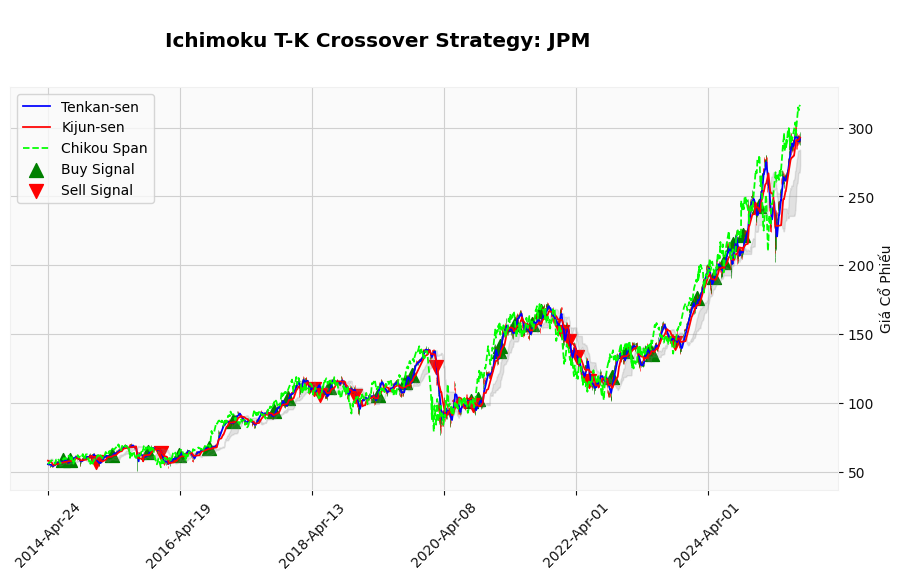

Đã vẽ và lưu biểu đồ cho mã: JPM


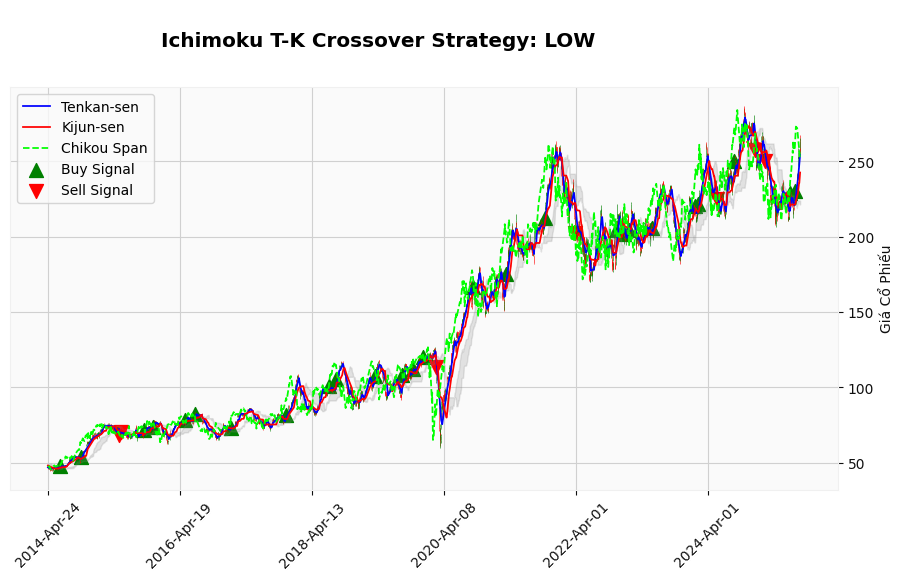

Đã vẽ và lưu biểu đồ cho mã: LOW


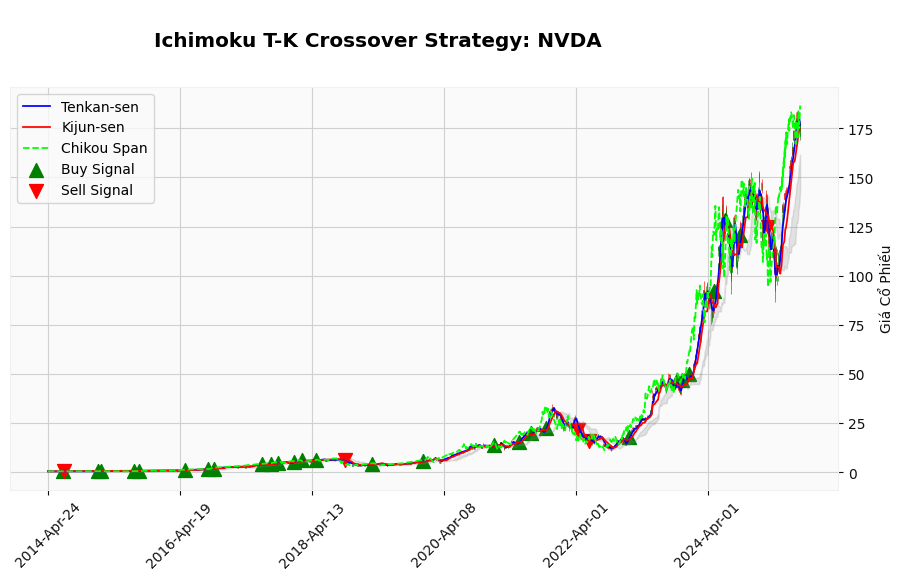

Đã vẽ và lưu biểu đồ cho mã: NVDA


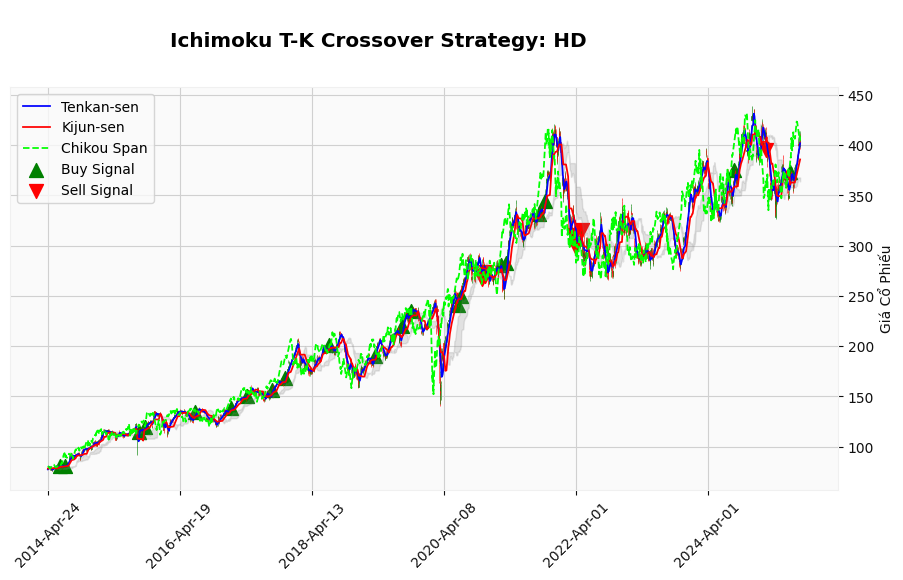

Đã vẽ và lưu biểu đồ cho mã: HD


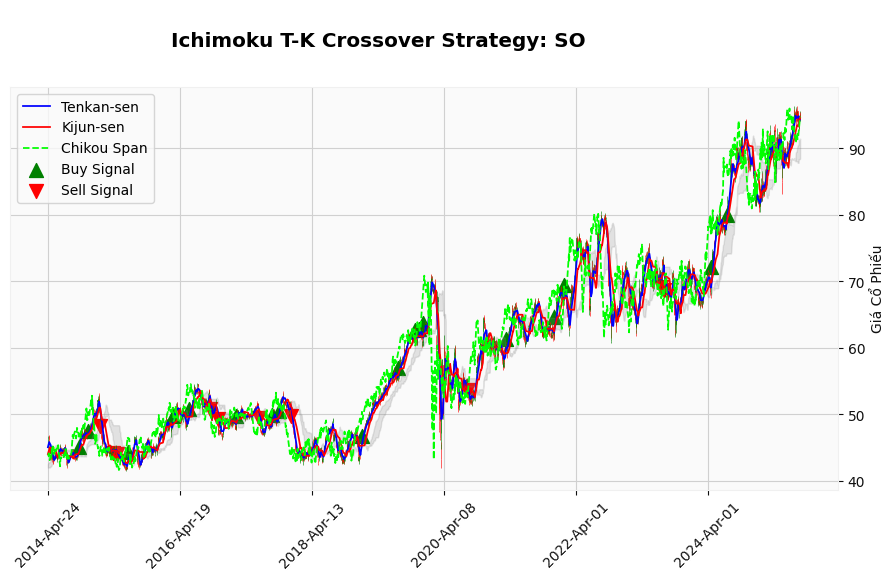

Đã vẽ và lưu biểu đồ cho mã: SO


In [18]:
!pip install mplfinance
import mplfinance as mpf
import pandas as pd
import numpy as np

top_5_stocks_ichimoku= performance_summary_df_ichimoku.sort_values(by='Sharpe_Ratio', ascending=False).head(5)

# --- 1. HÀM VẼ BIỂU ĐỒ ICHIMOKU (Ví dụ: cho 1 mã) ---
def plot_ichimoku_signals(df, ticker_name, initial_capital):

    # 1.1 Chuẩn bị dữ liệu Ichimoku và Kumo

    fills = [dict(y1=df['Senkou Span A'].to_numpy(), y2=df['Senkou Span B'].to_numpy(), color='gray', alpha=0.2)]

    # 1.2 Chuẩn bị các đường Ichimoku
    ichimoku_lines = [
        mpf.make_addplot(df['Tenkan-sen'], color='blue', label='Tenkan-sen'),
        mpf.make_addplot(df['Kijun-sen'], color='red', label='Kijun-sen'),
        mpf.make_addplot(df['Chikou Span'], color='lime', linestyle='--', label='Chikou Span', secondary_y=False)
    ]

    # 1.3 Chuẩn bị các tín hiệu MUA/BÁN
    # Tạo series rỗng với cùng index để đảm bảo kích thước phù hợp
    buy_markers = pd.Series(np.nan, index=df.index)
    sell_markers = pd.Series(np.nan, index=df.index)

    # Đặt giá Close vào những ngày có tín hiệu
    buy_markers[df['Signal'] == 1] = df['Close'][df['Signal'] == 1]
    sell_markers[df['Signal'] == -1] = df['Close'][df['Signal'] == -1]

    # Tạo các điểm đánh dấu (Markers)
    markers = []
    if not buy_markers.dropna().empty: # Check if there are actual buy signals
        markers.append(
            mpf.make_addplot(buy_markers, type='scatter', markersize=100, marker='^', color='green', label='Buy Signal')
        )
    if not sell_markers.dropna().empty: # Check if there are actual sell signals
        markers.append(
            mpf.make_addplot(sell_markers, type='scatter', markersize=100, marker='v', color='red', label='Sell Signal')
        )

    # 1.4 Tổng hợp các addplot
    addplots = ichimoku_lines + markers

    # 1.5 Cấu hình và Vẽ biểu đồ
    mc = mpf.make_marketcolors(up='green', down='red', wick='inherit', edge='inherit')
    s = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc, y_on_right=True)

    # Vẽ
    mpf.plot(
        df,
        type='candle',
        style=s,
        addplot=addplots,
        fill_between=fills,
        title=f"\nIchimoku T-K Crossover Strategy: {ticker_name}",
        ylabel='Giá Cổ Phiếu',
        volume=False,
        figratio=(16, 8),
        show_nontrading=False # Ẩn ngày không giao dịch
    )
    mpf.show()
    print(f"Đã vẽ và lưu biểu đồ cho mã: {ticker_name}")

# --- 2. THỰC THI CHO TOP 5 MÃ TỐT NHẤT ---

for ticker in top_5_stocks_ichimoku.index:
     if ticker in all_tickers:
        df_ichimoku = all_tickers[ticker].copy()
        # SHIFT = 26
        # ICHIMOKU_PARAMS = (9, 26, 52)
        # n1, n2, n3 = ICHIMOKU_PARAMS

        # LOGIC TÍN HIỆU ENTRY (Copied from backtest_ichimoku_tk_crossover)
        crossover_up = (df_ichimoku['Tenkan-sen'].shift(1) < df_ichimoku['Kijun-sen'].shift(1)) & (df_ichimoku['Tenkan-sen'] >= df_ichimoku['Kijun-sen'])
        crossover_down = (df_ichimoku['Tenkan-sen'].shift(1) > df_ichimoku['Kijun-sen'].shift(1)) & (df_ichimoku['Tenkan-sen'] <= df_ichimoku['Kijun-sen'])

        # Bộ lọc Mây Kumo
        above_kumo = (df_ichimoku['Close'] > df_ichimoku['Kumo_Top'])
        below_kumo = (df_ichimoku['Close'] < df_ichimoku['Kumo_Bottom'])

        # Chikou Span
        cs_above_price = (df_ichimoku['Chikou Span'] > df_ichimoku['Close'].shift(SHIFT))
        cs_below_price = (df_ichimoku['Chikou Span'] < df_ichimoku['Close'].shift(SHIFT))

        df_ichimoku['Signal'] = 0
        df_ichimoku['Signal'] = np.where(crossover_up & above_kumo & cs_above_price, 1, 0)
        df_ichimoku['Signal'] = np.where(crossover_down & below_kumo & cs_below_price, -1, df_ichimoku['Signal'])

        # Chạy hàm vẽ biểu đồ
        plot_ichimoku_signals(df_ichimoku, ticker, INITIAL_CAPITAL)
     else:
        print(f"Không tìm thấy dữ liệu Ichimoku cho mã {ticker}.")